In [1]:
## Load packages and cleaned data
import pandas as pd
import matplotlib.pyplot as plt

import os
os.chdir('/Users/gracewang/Documents/Hertie/Data Structures & Algorithms/project-chaggg')

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# district was saved as Int64 — restore it
df["district"] = pd.to_numeric(df["district"], errors="coerce").astype("Int64")

# Drop rows missing district or arrest
df = df.dropna(subset=["district", "arrest"])

                         primary_type  total_count  domestic_count  \
1          OFFENSE INVOLVING CHILDREN        60854           45350   
2                            STALKING         6295            3348   
3                             BATTERY      1543934          818490   
4                       OTHER OFFENSE       528906          196119   
5                          KIDNAPPING         7512            2614   
6                             ASSAULT       568814          166530   
8             CRIMINAL SEXUAL ASSAULT        39220            8176   
10                        SEX OFFENSE        34536            5714   
11                       INTIMIDATION         5142             782   
13                    CRIMINAL DAMAGE       963793          111084   
14                           HOMICIDE        14071             987   
15                              ARSON        14490             864   
16                  CRIMINAL TRESPASS       227863           11838   
17             PUBLI

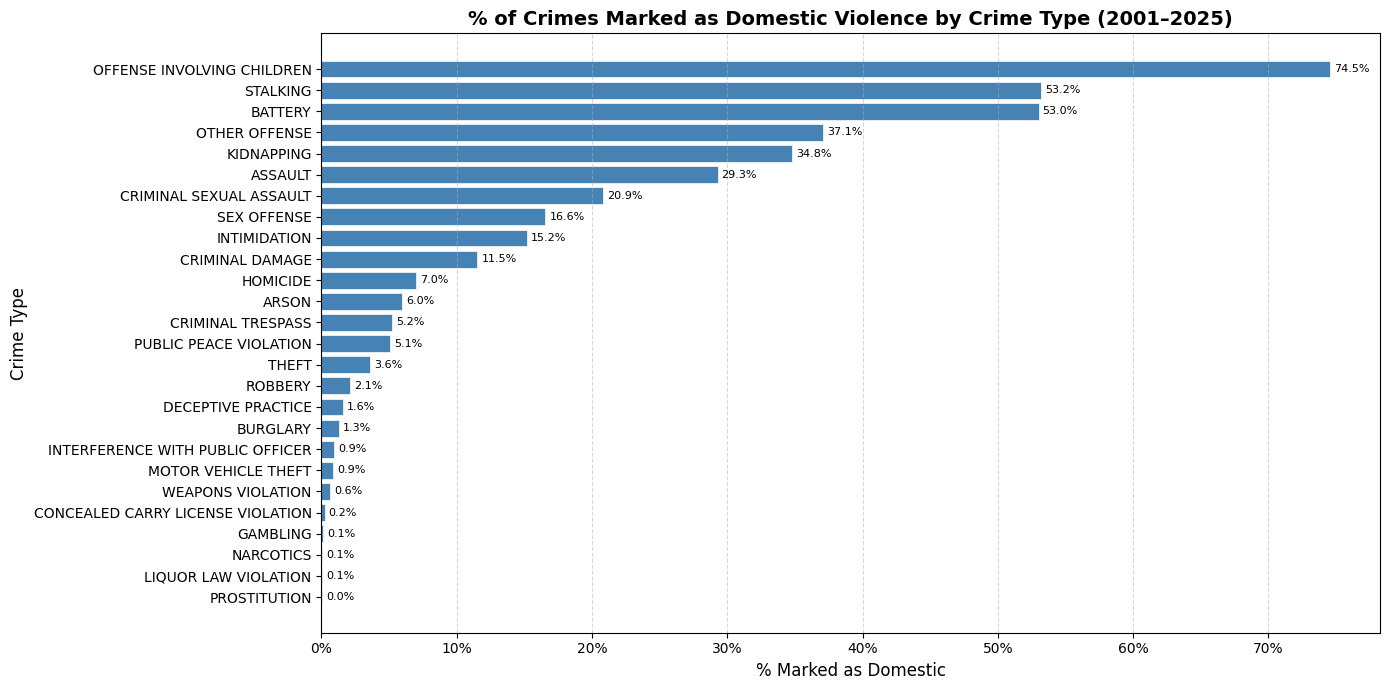

In [11]:
# Plot percentage of each crime type labeled domestic violence

# ── Standardize inconsistent primary_type labels ──────────────────────────────
type_remap = {
    "CRIM SEXUAL ASSAULT": "CRIMINAL SEXUAL ASSAULT",
}

df["primary_type"] = df["primary_type"].replace(type_remap)

# ── Calculate domestic rate by crime type ────────────────────────────────────
domestic_summary = (
    df.groupby("primary_type")
    .agg(
        total_count=("domestic", "count"),
        domestic_count=("domestic", "sum")
    )
    .assign(domestic_rate=lambda x: (x["domestic_count"] / x["total_count"] * 100).round(2))
    .sort_values("domestic_rate", ascending=False)
    .reset_index()
)

domestic_summary = domestic_summary[domestic_summary["total_count"] >= 1000]
print(domestic_summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    domestic_summary["primary_type"],
    domestic_summary["domestic_rate"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its percentage
for bar, val in zip(bars, domestic_summary["domestic_rate"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}%',
        ha="left", va="center", fontsize=8
    )

ax.set_xlabel("% Marked as Domestic", fontsize=12)
ax.set_ylabel("Crime Type", fontsize=12)
ax.set_title("% of Crimes Marked as Domestic Violence by Crime Type (2001–2025)", fontsize=14, fontweight="bold")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.invert_yaxis()  # highest % at the top
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("domestic_rate_by_crime_type.png", dpi=150)
plt.show()

In [9]:
# Table summarizing arrest rate by crime type

# ── Calculate arrest rate by crime type ──────────────────────────────────────
arrest_summary = (
    df.groupby("primary_type")
    .agg(
        total_count=("arrest", "count"),
        arrest_count=("arrest", "sum")
    )
    .assign(arrest_rate=lambda x: (x["arrest_count"] / x["total_count"] * 100).round(2))
    .sort_values("total_count", ascending=False)
    .reset_index()
)

# ── Rename columns for display ────────────────────────────────────────────────
arrest_summary.columns = ["Crime Type", "Total Count", "Arrest Count", "Arrest Rate %"]

# ── Format columns ────────────────────────────────────────────────────────────
arrest_summary["Total Count"]   = arrest_summary["Total Count"].apply(lambda x: f'{x:,}')
arrest_summary["Arrest Count"]  = arrest_summary["Arrest Count"].apply(lambda x: f'{x:,}')
arrest_summary["Arrest Rate %"] = arrest_summary["Arrest Rate %"].apply(lambda x: f'{x:.2f}%')

print(arrest_summary.to_string(index=False))

# ── Save to CSV ────────────────────────────────────────────────────
arrest_summary.to_csv('data/cleaned/arrest_rate_by_crime_type.csv', index=False)

                       Crime Type Total Count Arrest Count Arrest Rate %
                            THEFT   1,800,246      194,848        10.82%
                          BATTERY   1,543,934      334,430        21.66%
                  CRIMINAL DAMAGE     963,793       62,497         6.48%
                        NARCOTICS     765,152      760,073        99.34%
                          ASSAULT     568,814      114,729        20.17%
                    OTHER OFFENSE     528,906       93,504        17.68%
                         BURGLARY     447,879       25,570         5.71%
              MOTOR VEHICLE THEFT     434,813       32,743         7.53%
               DECEPTIVE PRACTICE     391,929       47,961        12.24%
                          ROBBERY     315,662       29,335         9.29%
                CRIMINAL TRESPASS     227,863      154,288        67.71%
                WEAPONS VIOLATION     125,814       91,430        72.67%
                     PROSTITUTION      70,455      

           primary_type  incident_count
32                THEFT         1800246
2               BATTERY         1543934
6       CRIMINAL DAMAGE          963793
19            NARCOTICS          765152
1               ASSAULT          568814
24        OTHER OFFENSE          528906
3              BURGLARY          447879
18  MOTOR VEHICLE THEFT          434813
9    DECEPTIVE PRACTICE          391929
29              ROBBERY          315662


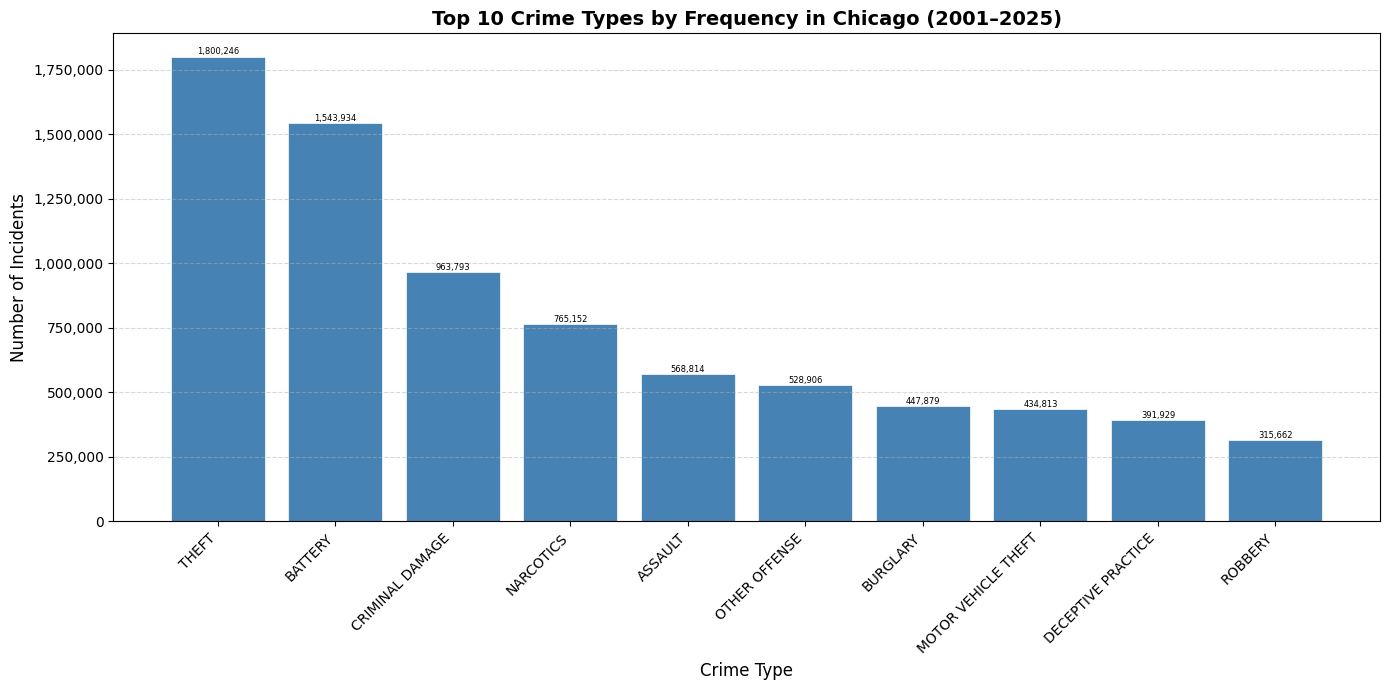

In [8]:
# Top 10 crime types by frequency

# ── Count crimes by primary type, sorted descending ──────────────────────────
type_counts = (
    df.groupby("primary_type")
    .size()
    .reset_index(name="incident_count")
    .sort_values("incident_count", ascending=False)
    .head(10)
)

print(type_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(
    type_counts["primary_type"],
    type_counts["incident_count"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its count
for bar, val in zip(bars, type_counts["incident_count"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'{int(val):,}',
        ha="center", va="bottom", fontsize=6
    )

ax.set_xlabel("Crime Type", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Top 10 Crime Types by Frequency in Chicago (2001–2025)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("crimes_by_primary_type.png", dpi=150)
plt.show()

    month  avg_incidents month_name
0       1       26460.72        Jan
1       2       23381.88        Feb
2       3       27658.08        Mar
3       4       27535.24        Apr
4       5       29957.32        May
5       6       29964.44        Jun
6       7       31530.68        Jul
7       8       31171.04        Aug
8       9       29379.32        Sep
9      10       29722.28        Oct
10     11       26748.80        Nov
11     12       25534.04        Dec


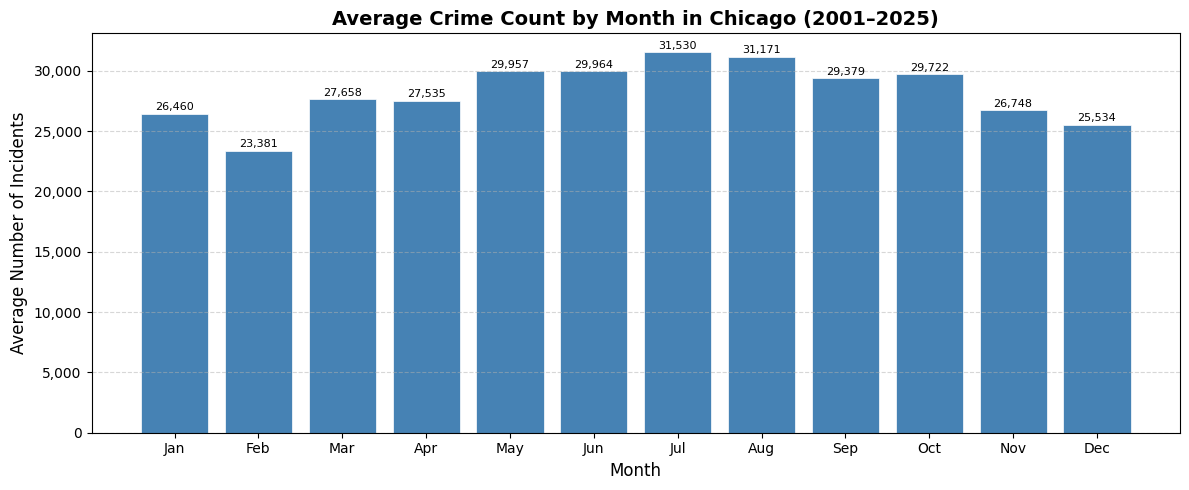

In [ ]:
# Plot avg crimes per month

#  ── Extract month from date ───────────────────────────────────────────────────
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month

# ── Count crimes per year-month, then average across years ───────────────────
monthly_avg = (
    df.groupby(["year", "month"])
    .size()
    .reset_index(name="incident_count")
    .groupby("month")["incident_count"]
    .mean()
    .reset_index(name="avg_incidents")
)

# ── Replace month numbers with names ─────────────────────────────────────────
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_avg["month_name"] = monthly_avg["month"].apply(lambda x: month_names[x - 1])

print(monthly_avg)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    monthly_avg["month_name"],
    monthly_avg["avg_incidents"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its value
for bar, val in zip(bars, monthly_avg["avg_incidents"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f'{int(val):,}',
        ha="center", va="bottom", fontsize=8
    )

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Average Number of Incidents", fontsize=12)
ax.set_title("Average Crime Count by Month in Chicago (2001–2025)", fontsize=14, fontweight="bold")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("avg_crimes_by_month.png", dpi=150)
plt.show()

    year  incident_count
0   2001          485958
1   2002          486831
2   2003          475999
3   2004          469443
4   2005          453788
5   2006          448198
6   2007          437108
7   2008          427216
8   2009          392866
9   2010          370567
10  2011          352052
11  2012          336375
12  2013          307612
13  2014          275880
14  2015          264887
15  2016          269959
16  2017          269287
17  2018          269147
18  2019          261702
19  2020          212700
20  2021          209656
21  2022          240002
22  2023          263282
23  2024          259007
24  2025          236574


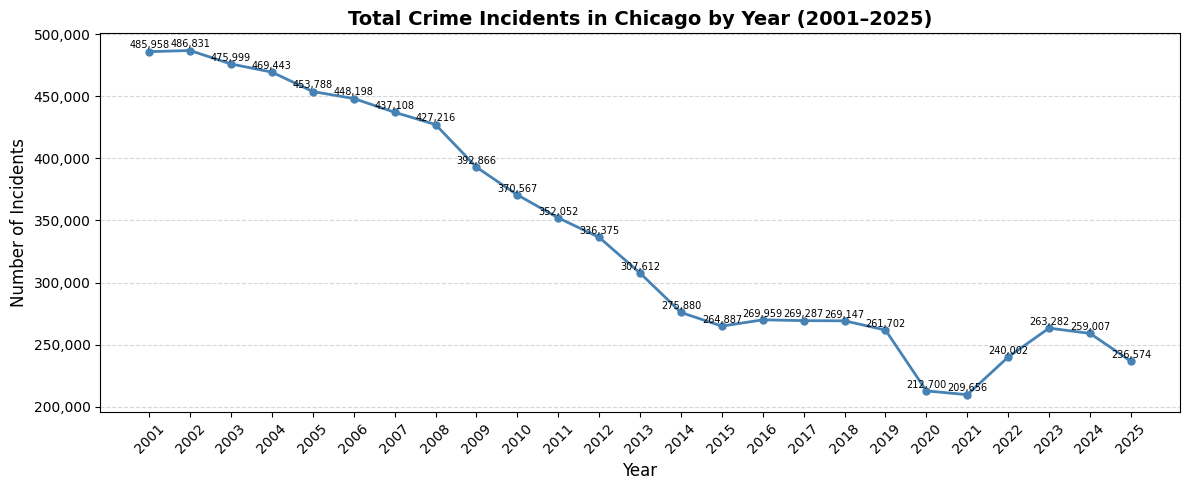

In [6]:
# Plot crime count by year

# ── Group by year and count incidents ────────────────────────────────────────
yearly_counts = (
    df.groupby("year")
    .size()
    .reset_index(name="incident_count")
    .sort_values("year")
)

print(yearly_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["incident_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Annotate each point with its count
for _, row in yearly_counts.iterrows():
    ax.text(
        row["year"],
        row["incident_count"] + 1000,
        f'{int(row["incident_count"]):,}',
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Total Crime Incidents in Chicago by Year (2001–2025)", fontsize=14, fontweight="bold")
ax.set_xticks(yearly_counts["year"])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("total_crimes_by_year.png", dpi=150)
plt.show()

    district  total_crimes  total_arrests  arrest_rate
0          1        353854          92281    26.078835
1          2        404345          99544    24.618581
2          3        430337         104970    24.392511
3          4        479818         102960    21.458136
4          5        372350          91221    24.498724
5          6        495170         122384    24.715552
6          7        479212         130839    27.302947
7          8        568335         123981    21.814775
8          9        410967         109677    26.687544
9         10        363749         111515    30.657129
10        11        537285         220226    40.988675
11        12        428476          91735    21.409601
12        14        326153          64395    19.743801
13        15        356490         134678    37.778900
14        16        285033          51904    18.209821
15        17        245761          48983    19.931153
16        18        385873          86500    22.416702
17        

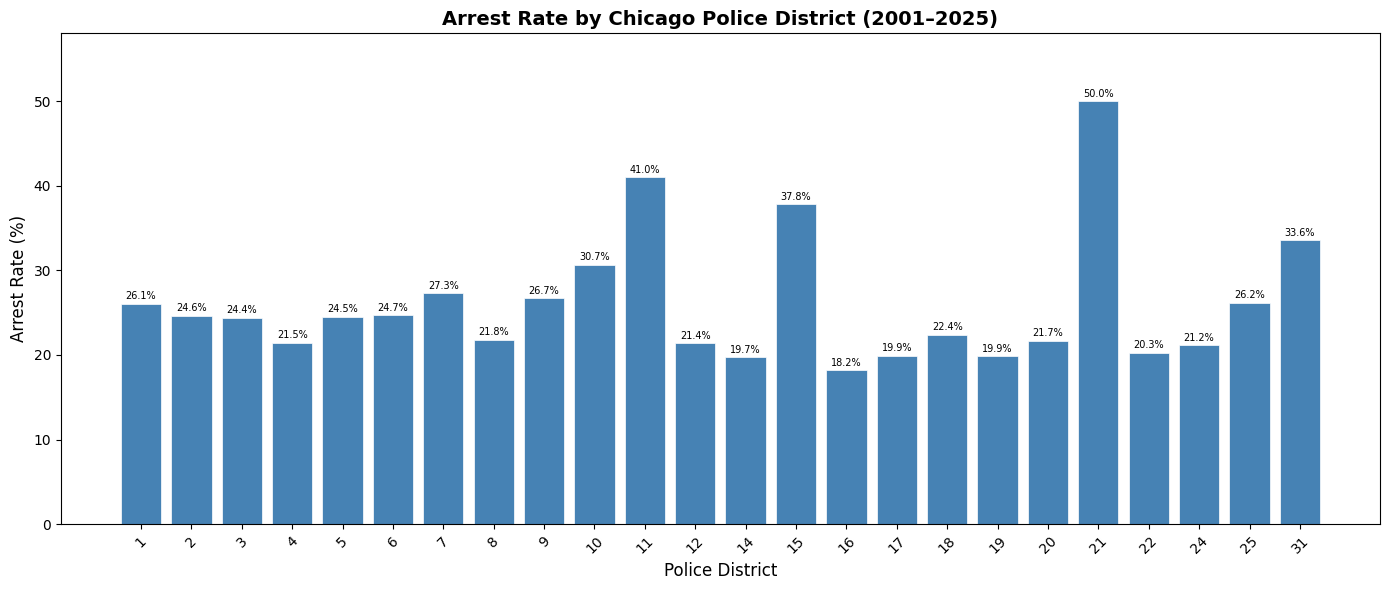

In [2]:
## Plot arrest rates by district into bar chart


# ── Calculate arrest rate per district ───────────────────────────────────────
summary = (
    df.groupby("district")
    .agg(
        total_crimes=("arrest", "count"),
        total_arrests=("arrest", "sum")
    )
    .assign(arrest_rate=lambda x: x["total_arrests"] / x["total_crimes"] * 100)
    .sort_values("district")
    .reset_index()
)

print(summary)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(
    summary["district"].astype(str),
    summary["arrest_rate"],
    color="steelblue",
    edgecolor="white",
    linewidth=0.5
)

# Annotate each bar with its rate
for bar, rate in zip(bars, summary["arrest_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Police District", fontsize=12)
ax.set_ylabel("Arrest Rate (%)", fontsize=12)
ax.set_title("Arrest Rate by Chicago Police District (2001–2025)", fontsize=14, fontweight="bold")
ax.set_ylim(0, summary["arrest_rate"].max() + 8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("arrest_rate_by_district.png", dpi=150)
plt.show()

    year  incident_count
1   2002           82594
2   2003           76585
3   2004           75026
4   2005           70724
5   2006           69208
6   2007           70434
7   2008           69368
8   2009           65273
9   2010           61387
10  2011           58253
11  2012           55576
12  2013           52074
13  2014           47546
14  2015           49005
15  2016           50842
16  2017           50510
17  2018           51881
18  2019           51238
19  2020           46322
20  2021           47927
21  2022           44988
22  2023           47075
23  2024           47588


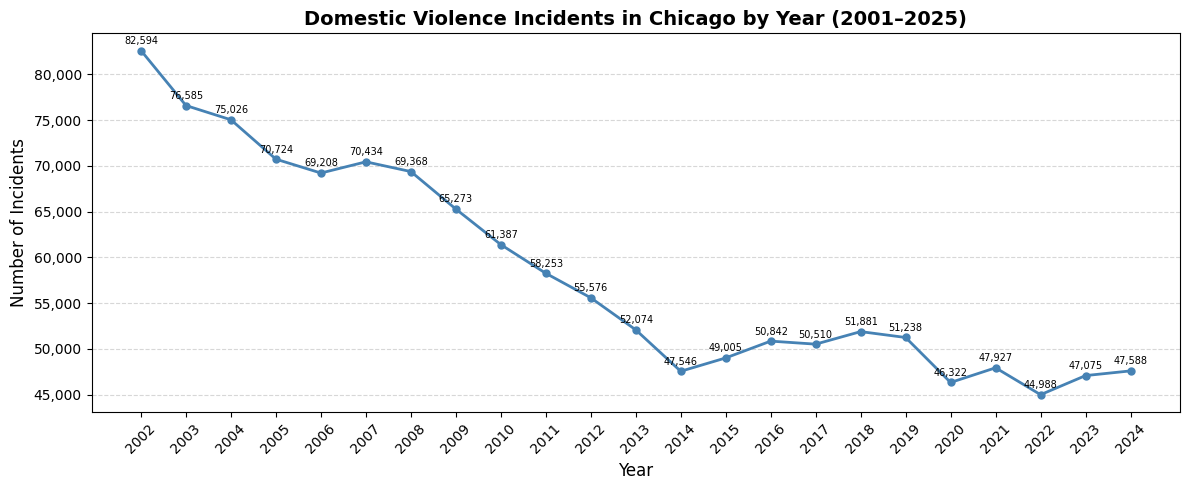

In [3]:
## Plot annual domestic violence incident count over time (2001–2025)

import pandas as pd
import matplotlib.pyplot as plt

# ── Load cleaned data ─────────────────────────────────────────────────────────
df = pd.read_csv('data/cleaned/chicago_crimes_cleaned.csv', low_memory=False)

# ── Filter for domestic violence crimes ──────────────────────────────────────
domestic = df[df["domestic"] == True]

# ── Group by year and count incidents ────────────────────────────────────────
yearly_counts = (
    domestic.groupby("year")
    .size()
    .reset_index(name="incident_count")
    .sort_values("year")
)

# Drop 2001 (high missing data) and 2025 (incomplete year)
yearly_counts = yearly_counts[yearly_counts["year"].between(2002, 2024)]

print(yearly_counts)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    yearly_counts["year"],
    yearly_counts["incident_count"],
    color="steelblue",
    linewidth=2,
    marker="o",
    markersize=5
)

# Annotate each point with its count
for _, row in yearly_counts.iterrows():
    ax.text(
        row["year"],
        row["incident_count"] + 500,
        f'{int(row["incident_count"]):,}',
        ha="center", va="bottom", fontsize=7
    )

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Number of Incidents", fontsize=12)
ax.set_title("Domestic Violence Incidents in Chicago by Year (2001–2025)", fontsize=14, fontweight="bold")
ax.set_xticks(yearly_counts["year"])
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("domestic_violence_by_year.png", dpi=150)

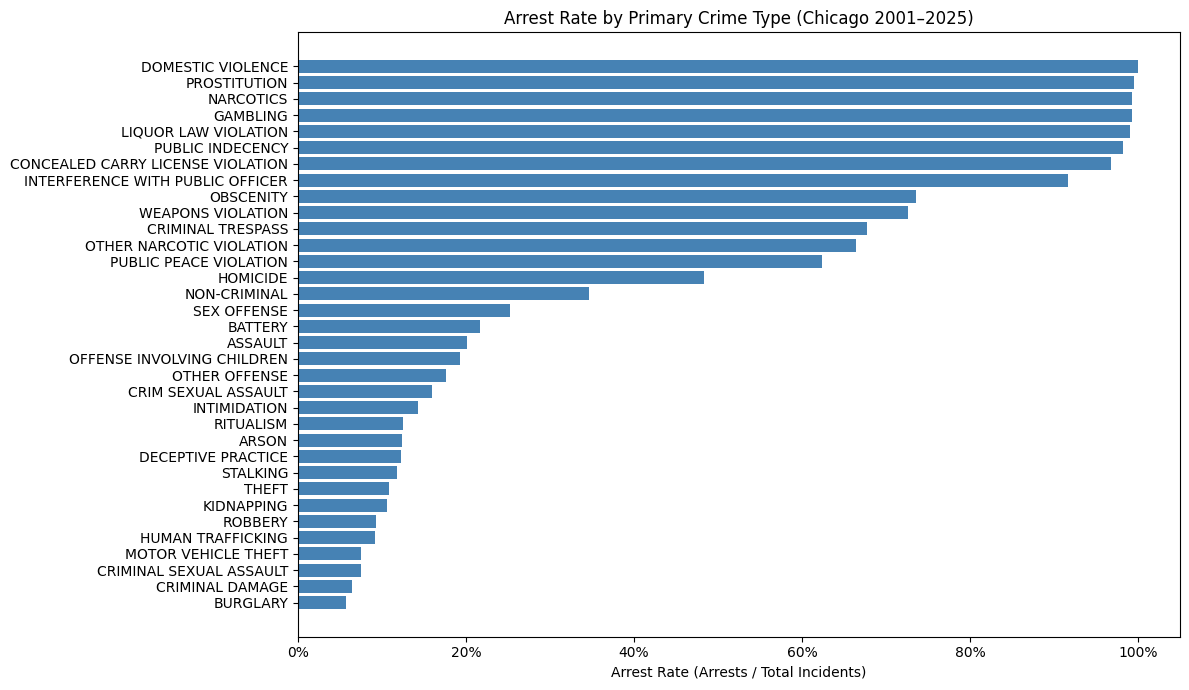

In [4]:
# Arrest rates by primary crime type
arrest_rates = (
    df.groupby("primary_type")
    .agg(total=("arrest", "count"), arrests=("arrest", "sum"))
    .assign(arrest_rate=lambda x: x["arrests"] / x["total"])
    .sort_values("arrest_rate", ascending=False)
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(arrest_rates["primary_type"], arrest_rates["arrest_rate"], color="steelblue")
ax.invert_yaxis()
ax.set_xlabel("Arrest Rate (Arrests / Total Incidents)")
ax.set_title("Arrest Rate by Primary Crime Type (Chicago 2001–2025)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
plt.tight_layout()
plt.savefig("arrest_rate_by_primary_crime_type.png", dpi=150)
plt.show()

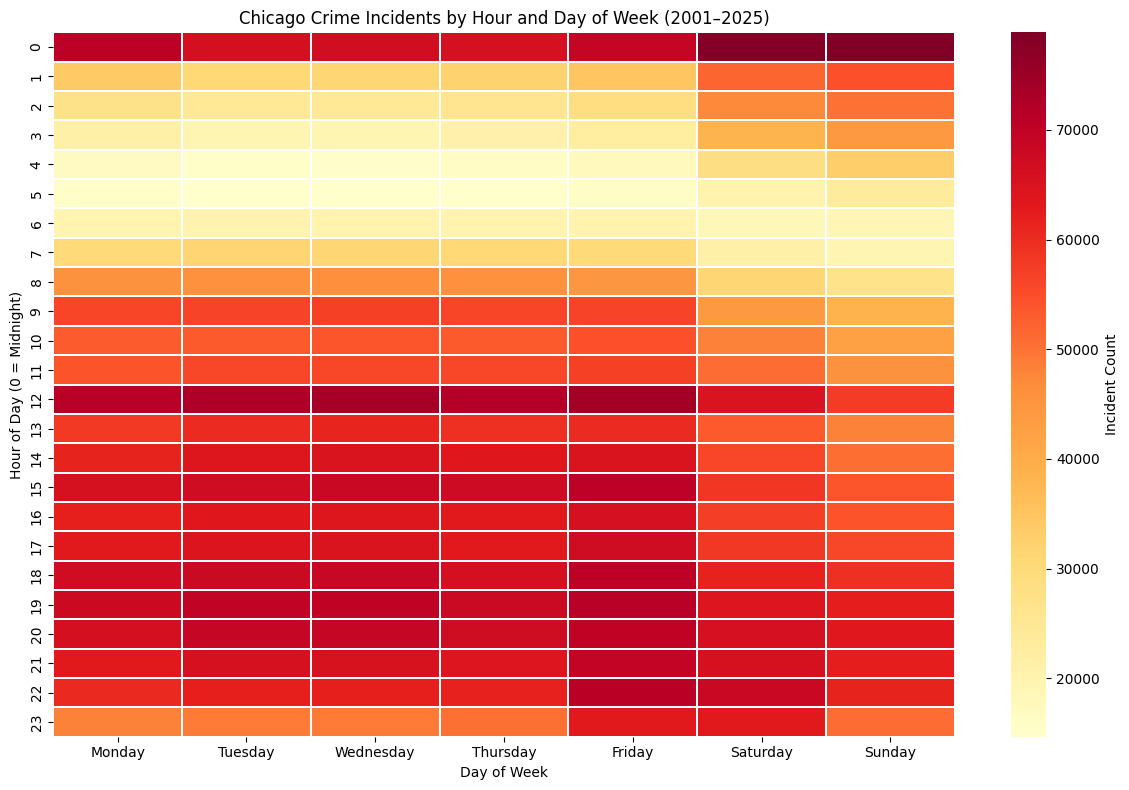

In [5]:
## Plot incident count by time of day (hour) and day of week (M, T, W, Th, etc.)
import seaborn as sns

# Parse date column if not already done
df["Date"] = pd.to_datetime(df["date"])
df["Time"] = pd.to_datetime(df["time"], format="%H:%M:%S")
df["Hour"] = df["Time"].dt.hour
df["DayOfWeek"] = df["Date"].dt.day_name()

# Pivot into hour x day matrix
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
heatmap_data = (
    df.groupby(["Hour", "DayOfWeek"])
    .size()
    .unstack("DayOfWeek")
    .reindex(columns=day_order)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    ax=ax,
    fmt=",",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Incident Count"}
)
ax.set_title("Chicago Crime Incidents by Hour and Day of Week (2001–2025)")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day (0 = Midnight)")
plt.tight_layout()
plt.savefig("crimes_by_hour_and_day_of_week.png", dpi=150)
plt.show()